# 뉴스 크롤링 & 분석

이 노트북에서 할 일:
1. 네이버 뉴스에서 기사 목록 수집
2. 판다스 DataFrame으로 정리
3. 간단한 분석 (많이 나온 단어 등)

## 1단계: 라이브러리 불러오기

In [84]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

# 크롤링할 때 브라우저처럼 보이게 하는 헤더
headers = {
    'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 Chrome/120.0.0.0 Safari/537.36'
}

print('준비 완료!')

준비 완료!


## 2단계: 뉴스 기사 목록 수집

네이버 뉴스 IT 섹션에서 기사 제목과 링크를 가져옵니다.

In [85]:
def get_naver_news(section_url, pages=1):
    articles = []
    for page in range(1, pages + 1):
        url = f'{section_url}&page={page}'
        response = requests.get(url, headers=headers)
        soup = BeautifulSoup(response.text, 'lxml')
        items = soup.select('ul.type06_headline li dl dt:not(.photo) a')
        for item in items:
            articles.append({'제목': item.text.strip(), '링크': item['href']})
        time.sleep(0.5)
    return articles

print('함수 준비 완료!')

함수 준비 완료!


## 3단계: 여러 섹션에서 수집하기

In [86]:
PAGES = 20

all_articles = get_naver_news(
    'https://news.naver.com/main/list.naver?mode=LSD&mid=sec&sid1=101',
    pages=PAGES
)

print(f'수집 완료: 총 {len(all_articles)}개 기사')

수집 완료: 총 200개 기사


## 4단계: DataFrame으로 정리

In [87]:
df = pd.DataFrame(all_articles)
df = df[['제목', '링크']]
df = df.drop_duplicates(subset='제목').reset_index(drop=True)

print(f'데이터 크기: {len(df)}개 기사')
df.head(10)

데이터 크기: 200개 기사


,제목,링크
0,"""삼전닉스 HBM 탑재한 베라루빈 양산 돌입""",https://n.news.naver.com/mnews/article/015/000...
1,"국민성장펀드, 손실 나도 소득세 낸다는데 …",https://n.news.naver.com/mnews/article/015/000...
2,코스피 시총 7000조 돌파…삼전도 2000조,https://n.news.naver.com/mnews/article/011/000...
3,"[마켓인]한신평 “삼양사, 日향료기업 인수에 차입 부담 확대”",https://n.news.naver.com/mnews/article/018/000...
4,"국토부, 새 슬로건 ‘미래를 짓다 모두를 잇다’ 발표",https://n.news.naver.com/mnews/article/138/000...
5,"[단독]‘反하나’ 코인 연합군, 신한금융그룹도 가세",https://n.news.naver.com/mnews/article/011/000...
6,국민은행 앱 ‘리브똑똑’ 금융서비스 30일 종료,https://n.news.naver.com/mnews/article/011/000...
7,이재용 주식 가치 60조 넘어…李 정부 출범 후 47조 급증,https://n.news.naver.com/mnews/article/082/000...
8,"'블랙홀 규명' 오성진, '30년 한센인 인술' 오동찬 등 6명 삼성호암상",https://n.news.naver.com/mnews/article/469/000...
9,‘베트남’ 현지 서비스 강화 나선 마이리얼트립... 36개 지점 QR 예약 연결,https://n.news.naver.com/mnews/article/243/000...


## 4-1단계: 주식 관련 뉴스만 필터링

In [88]:
# 주식 관련 키워드 목록
stock_keywords = [
    '주식', '증시', '코스피', '코스닥', '주가', '상장', '상장폐지',
    '매수', '매도', '종목', '배당', '증권', 'ETF', '펀드', '시가총액',
    '공모주', '유상증자', '주주', '거래량', '급등', '급락', '강세', '약세'
]

# 제목에 키워드가 하나라도 포함되면 True
pattern = '|'.join(stock_keywords)
stock_df = df[df['제목'].str.contains(pattern, na=False)].reset_index(drop=True)

print(f'전체 기사: {len(df)}개')
print(f'주식 관련 기사: {len(stock_df)}개')
print()
stock_df

전체 기사: 200개
주식 관련 기사: 33개



,제목,링크
0,"국민성장펀드, 손실 나도 소득세 낸다는데 …",https://n.news.naver.com/mnews/article/015/000...
1,코스피 시총 7000조 돌파…삼전도 2000조,https://n.news.naver.com/mnews/article/011/000...
2,이재용 주식 가치 60조 넘어…李 정부 출범 후 47조 급증,https://n.news.naver.com/mnews/article/082/000...
3,삼전닉스 2배에 37조 '베팅'…반도체ETF선 '매도',https://n.news.naver.com/mnews/article/215/000...
4,"주식으로 쏠렸나…성수기 무색해진 車 업계, 5월 내수 '뚝' (종합)",https://n.news.naver.com/mnews/article/119/000...
5,여의도서 첫 임원회의…증권·운용 힘싣는 진옥동,https://n.news.naver.com/mnews/article/015/000...
6,‘젠슨 황 효과’에 8800 돌파한 코스피···LG·네이버·두산 주가 불기둥,https://n.news.naver.com/mnews/article/032/000...
7,코스피 고공행진 속 포스트워 투자전략,https://n.news.naver.com/mnews/article/015/000...
8,"언론노조, 기자 투자 가이드라인 마련…“취재정보로 주식투자 금지”",https://n.news.naver.com/mnews/article/056/001...
9,'삼성전자 보통주 시총 2000조원' 돌파에 코스피 첫 8700 고지,https://n.news.naver.com/mnews/article/018/000...


## 5단계: 기초 분석

In [89]:
print(f'총 기사 수: {len(df)}개')
print(f'평균 제목 길이: {df["제목"].str.len().mean():.1f}자')

총 기사 수: 200개
평균 제목 길이: 33.4자


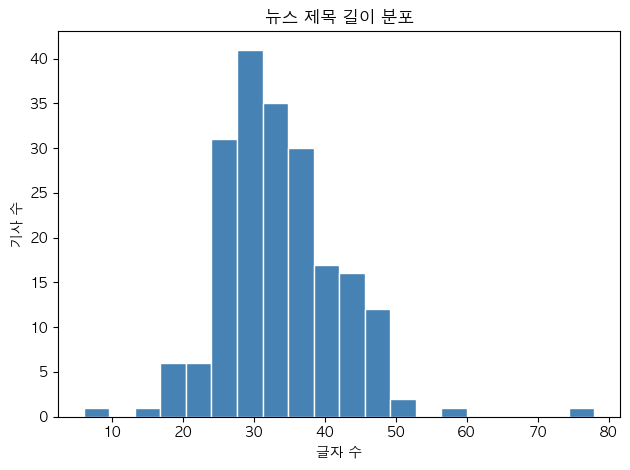

In [90]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 제목 길이 분포
df['제목'].str.len().plot(kind='hist', bins=20, color='steelblue', edgecolor='white')
plt.title('뉴스 제목 길이 분포')
plt.xlabel('글자 수')
plt.ylabel('기사 수')
plt.tight_layout()
plt.show()

In [91]:
# 제목에서 자주 등장하는 단어 찾기
from collections import Counter

# 모든 제목을 합쳐서 단어로 쪼개기
all_words = ' '.join(df['제목']).split()

# 너무 짧은 단어(1~2글자) 제외
words = [w for w in all_words if len(w) >= 3]

# 자주 등장하는 단어 상위 15개
word_counts = Counter(words).most_common(15)
print('=== 자주 등장한 단어 TOP 15 ===')
for word, count in word_counts:
    print(f'  {word}: {count}회')

=== 자주 등장한 단어 TOP 15 ===
  코스피: 9회
  이재용: 7회
  글로벌: 5회
  삼성전자: 4회
  [포토]: 4회
  삼성,: 4회
  10%: 4회
  삼성호암상: 3회
  서비스: 3회
  회장,: 3회
  대만서: 3회
  8400억원: 3회
  열병합발전소: 3회
  엔비디아: 3회
  판매…전년比: 3회


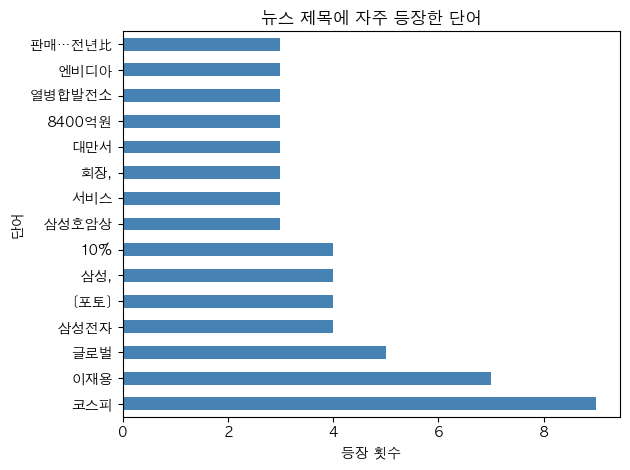

In [92]:
# 자주 등장한 단어 시각화
words_df = pd.DataFrame(word_counts, columns=['단어', '횟수'])

words_df.plot(kind='barh', x='단어', y='횟수', color='steelblue', legend=False)
plt.title('뉴스 제목에 자주 등장한 단어')
plt.xlabel('등장 횟수')
plt.tight_layout()
plt.show()

## 6단계: CSV로 저장

In [93]:
# 전체 뉴스 저장
df.to_csv('../data/news.csv', index=False, encoding='utf-8-sig')
print(f'전체 뉴스 저장 완료: {len(df)}개 → data/news.csv')

# 주식 관련 뉴스만 따로 저장
stock_df.to_csv('../data/news_stock.csv', index=False, encoding='utf-8-sig')
print(f'주식 뉴스 저장 완료: {len(stock_df)}개 → data/news_stock.csv')

전체 뉴스 저장 완료: 200개 → data/news.csv
주식 뉴스 저장 완료: 33개 → data/news_stock.csv


## 7단계: 내일 급등 예상 종목 추측

> ⚠️ 투자 참고용이 아닌 순수 학습/실습 목적입니다.

In [94]:
import FinanceDataReader as fdr
import yfinance as yf

# KOSPI / KOSDAQ 따로 불러서 시장 구분 추가 (야후파이낸스 티커용)
kospi = fdr.StockListing('KOSPI')[['Code', 'Name']]; kospi['Market'] = 'KS'
kosdaq = fdr.StockListing('KOSDAQ')[['Code', 'Name']]; kosdaq['Market'] = 'KQ'
krx = pd.concat([kospi, kosdaq], ignore_index=True)
krx = krx[krx['Name'].str.len() >= 3].reset_index(drop=True)

# 뉴스 제목에서 언급 횟수 카운트
import re
all_titles = ' '.join(df['제목'])
krx['언급횟수'] = krx['Name'].apply(
    lambda name: len(re.findall(r'(?<!\w)' + re.escape(name) + r'(?!\w)', all_titles))
)

result = (
    krx[krx['언급횟수'] > 0]
    .sort_values('언급횟수', ascending=False)
    .reset_index(drop=True)
)

print(f'뉴스에 언급된 종목 수: {len(result)}개')
print()
print('=== 내일 급등 예상 종목 TOP 10 (언급 빈도 기준) ===')
result.head(10)

뉴스에 언급된 종목 수: 19개

=== 내일 급등 예상 종목 TOP 10 (언급 빈도 기준) ===


,Code,Name,Market,언급횟수
0,005930,삼성전자,KS,6
1,034020,두산에너빌리티,KS,2
2,066570,LG전자,KS,2
3,128940,한미약품,KS,2
4,145990,삼양사,KS,1
5,076610,해성옵틱스,KQ,1
6,078340,컴투스,KQ,1
7,039200,오스코텍,KQ,1
8,214450,파마리서치,KQ,1
9,001250,GS글로벌,KS,1


## 8단계: 예측 종목 실시간 현재가 조회

In [95]:
def get_price(code, market):
    try:
        ticker = yf.Ticker(f'{code}.{market}')
        info = ticker.fast_info
        prev  = info.previous_close
        last  = info.last_price
        change_pct = (last - prev) / prev * 100 if prev else None
        return pd.Series({
            '현재가': int(last) if last else None,
            '전일비(%)': round(change_pct, 2) if change_pct else None,
            '시가총액(억)': int(info.market_cap / 1e8) if info.market_cap else None,
        })
    except:
        return pd.Series({'현재가': None, '전일비(%)': None, '시가총액(억)': None})

top = result.head(10).copy()
print('시세 조회 중...')
price_data = top.apply(lambda row: get_price(row['Code'], row['Market']), axis=1)
top = pd.concat([top, price_data], axis=1)

# 예상 상승률 계산
# 공식: 언급 횟수가 많을수록 상승폭이 크다고 가정
# 최대 언급 종목 기준으로 0.5%~3.0% 범위로 선형 스케일
# ⚠️ 실제 투자 근거 없는 단순 수식입니다
max_mentions = top['언급횟수'].max()
min_pct, max_pct = 0.5, 3.0
top['예상상승률(%)'] = (
    (top['언급횟수'] / max_mentions) * (max_pct - min_pct) + min_pct
).round(2)
top['예상상승금액(원)'] = (
    top['현재가'] * top['예상상승률(%)'] / 100
).round(0).astype('Int64')
top['예상내일가(원)'] = (
    top['현재가'] + top['예상상승금액(원)']
).astype('Int64')

print()
cols = ['Name', '언급횟수', '현재가', '전일비(%)', '예상상승률(%)', '예상상승금액(원)', '예상내일가(원)']
top[cols].style.format({
    '현재가': '{:,}',
    '예상상승금액(원)': '{:,}',
    '예상내일가(원)': '{:,}',
    '예상상승률(%)': '{:.2f}%',
    '전일비(%)': '{:+.2f}%',
})

시세 조회 중...



,Name,언급횟수,현재가,전일비(%),예상상승률(%),예상상승금액(원),예상내일가(원)
0,삼성전자,6,"349,000.0",+10.09%,3.00%,"10,470","359,470"
1,두산에너빌리티,2,"106,900.0",+1.23%,1.33%,"1,422","108,322"
2,LG전자,2,"380,500.0",+29.86%,1.33%,"5,061","385,561"
3,한미약품,2,"539,000.0",+9.78%,1.33%,"7,169","546,169"
4,삼양사,1,"44,100.0",+2.44%,0.92%,406,"44,506"
5,해성옵틱스,1,"1,822.0",-5.55%,0.92%,17,"1,839"
6,컴투스,1,"25,900.0",-2.45%,0.92%,238,"26,138"
7,오스코텍,1,"40,550.0",-3.57%,0.92%,373,"40,923"
8,파마리서치,1,"298,000.0",+1.02%,0.92%,"2,742","300,742"
9,GS글로벌,1,"3,115.0",-4.01%,0.92%,29,"3,144"


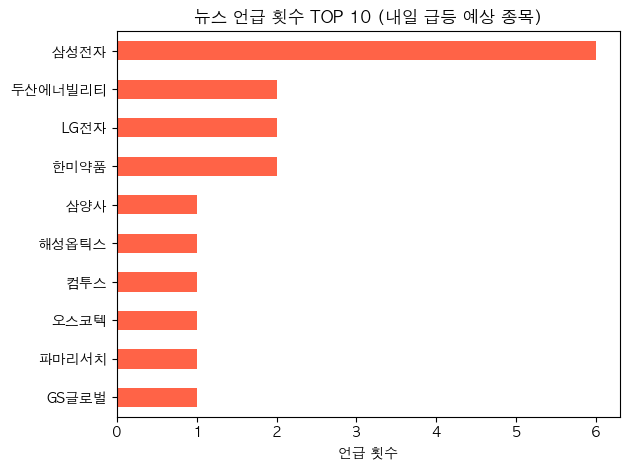

저장 완료 → data/predicted_stocks.csv


In [96]:
# 시각화
top10 = result.head(10)

top10.plot(
    kind='barh', x='Name', y='언급횟수',
    color='tomato', legend=False
)
plt.title('뉴스 언급 횟수 TOP 10 (내일 급등 예상 종목)')
plt.xlabel('언급 횟수')
plt.ylabel('')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# CSV 저장
result.to_csv('../data/predicted_stocks.csv', index=False, encoding='utf-8-sig')
print('저장 완료 → data/predicted_stocks.csv')